In [1]:
import pyodbc

In [2]:
# 파일 경로 (바탕화면)
mdb_path = r"C:\Users\user\Desktop\avall.mdb"

# 연결
conn_str = (
    r"DRIVER={Microsoft Access Driver (*.mdb, *.accdb)};"
    rf"DBQ={mdb_path};"
)
conn = pyodbc.connect(conn_str)
cursor = conn.cursor()

# 테이블 목록 출력
tables = [row.table_name for row in cursor.tables(tableType='TABLE')]
print(f"총 {len(tables)} 개 테이블:")
for t in tables:
    print(f"  - {t}")

conn.close()

Error: ('HY000', "[HY000] [Microsoft][ODBC Microsoft Access 드라이버] '(알 수 없음)' 파일을 찾을 수 없습니다. (-1811) (SQLDriverConnect); [HY000] [Microsoft][ODBC Microsoft Access 드라이버] '(알 수 없음)' 파일을 찾을 수 없습니다. (-1811)")

In [3]:
# 바탕화면의 파일 목록 보기
import os

# 진짜 사용자 폴더 경로
home = os.path.expanduser("~")
desktop = os.path.join(home, "Desktop")

print(f"홈 폴더: {home}")
print(f"바탕화면: {desktop}")
print(f"바탕화면 존재? {os.path.exists(desktop)}")
print()

# 바탕화면에 있는 파일들
if os.path.exists(desktop):
    print("바탕화면 파일들:")
    for f in os.listdir(desktop):
        if 'avall' in f.lower() or '.mdb' in f.lower():
            full_path = os.path.join(desktop, f)
            size_mb = os.path.getsize(full_path) / (1024*1024)
            print(f"  ✅ {full_path} ({size_mb:.1f} MB)")

홈 폴더: C:\Users\user
바탕화면: C:\Users\user\Desktop
바탕화면 존재? True

바탕화면 파일들:
  ✅ C:\Users\user\Desktop\avall.zip (89.7 MB)


In [4]:
import zipfile
import os

zip_path = r"C:\Users\user\Desktop\avall.zip"
extract_to = r"C:\Users\user\Desktop"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    print("zip 안 파일들:")
    for name in zip_ref.namelist():
        print(f"  - {name}")
    print("\n압축 푸는 중...")
    zip_ref.extractall(extract_to)

print("✅ 완료!")

# 풀린 파일 확인
for f in os.listdir(extract_to):
    if 'avall' in f.lower() and f.endswith('.mdb'):
        full = os.path.join(extract_to, f)
        size_mb = os.path.getsize(full) / (1024*1024)
        print(f"\n발견: {full} ({size_mb:.1f} MB)")

zip 안 파일들:
  - avall.mdb

압축 푸는 중...
✅ 완료!

발견: C:\Users\user\Desktop\avall.mdb (521.0 MB)


In [5]:
# 파일 경로 (바탕화면)
mdb_path = r"C:\Users\user\Desktop\avall.mdb"

# 연결
conn_str = (
    r"DRIVER={Microsoft Access Driver (*.mdb, *.accdb)};"
    rf"DBQ={mdb_path};"
)
conn = pyodbc.connect(conn_str)
cursor = conn.cursor()

# 테이블 목록 출력
tables = [row.table_name for row in cursor.tables(tableType='TABLE')]
print(f"총 {len(tables)} 개 테이블:")
for t in tables:
    print(f"  - {t}")

conn.close()

총 20 개 테이블:
  - aircraft
  - Country
  - ct_iaids
  - ct_seqevt
  - dt_aircraft
  - dt_events
  - dt_Flight_Crew
  - eADMSPUB_DataDictionary
  - engines
  - events
  - Events_Sequence
  - Findings
  - Flight_Crew
  - flight_time
  - injury
  - narratives
  - NTSB_Admin
  - Occurrences
  - seq_of_events
  - states


In [6]:
import pandas as pd
import pyodbc

mdb_path = r"C:\Users\user\Desktop\avall.mdb"
conn_str = (
    r"DRIVER={Microsoft Access Driver (*.mdb, *.accdb)};"
    rf"DBQ={mdb_path};"
)
conn = pyodbc.connect(conn_str)

df_sample = pd.read_sql("SELECT TOP 5 * FROM Findings", conn)

print(f"Findings 테이블 컬럼 ({len(df_sample.columns)}개):")
for col in df_sample.columns:
    print(f"  - {col}")

print("\n첫 5행:")
print(df_sample)

conn.close()

C:\Users\user\AppData\Local\Temp\ipykernel_11516\3834416483.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_sample = pd.read_sql("SELECT TOP 5 * FROM Findings", conn)


Findings 테이블 컬럼 (14개):
  - ev_id
  - Aircraft_Key
  - finding_no
  - finding_code
  - finding_description
  - category_no
  - subcategory_no
  - section_no
  - subsection_no
  - modifier_no
  - Cause_Factor
  - lchg_date
  - lchg_userid
  - cm_inPc

첫 5행:
            ev_id  Aircraft_Key  finding_no finding_code  \
0  20080107X00026             1           1   0204151045   
1  20080107X00026             2           1   0204151044   
2  20080109X00036             1           1   0303404099   
3  20080109X00036             1           2   0106202020   
4  20080107X00027             1           1   0303602099   

                                 finding_description category_no  \
0  Personnel issues-Action/decision-Info processi...          02   
1  Personnel issues-Action/decision-Info processi...          02   
2  Environmental issues-Conditions/weather/phenom...          03   
3  Aircraft-Aircraft oper/perf/capability-Perform...          01   
4  Environmental issues-Conditions/weather/

In [7]:
# Phase A: Cross-tabulation of category x Cause/Factor
# Question: How does NTSB code findings as Cause vs Factor across categories?

import pandas as pd
import pyodbc

mdb_path = r"C:\Users\user\Desktop\avall.mdb"
conn_str = (
    r"DRIVER={Microsoft Access Driver (*.mdb, *.accdb)};"
    rf"DBQ={mdb_path};"
)
conn = pyodbc.connect(conn_str)

# Get all findings with category and Cause/Factor flag
df = pd.read_sql("""
    SELECT category_no, Cause_Factor 
    FROM Findings 
    WHERE Cause_Factor IS NOT NULL
""", conn)
conn.close()

print(f"Total findings: {len(df):,}")
print(f"Cause_Factor values: {df['Cause_Factor'].unique()}")
print()

# Category number to name mapping
category_names = {
    '01': 'Aircraft',
    '02': 'Personnel',
    '03': 'Environmental',
    '04': 'Organizational'
}
df['category_name'] = df['category_no'].map(category_names)

# Cross-tabulation
crosstab = pd.crosstab(df['category_name'], df['Cause_Factor'])
print("Crosstab (Category x Cause/Factor):")
print(crosstab)

# Calculate C:F ratio for each category
print("\nCause-to-Factor ratio by category:")
for cat in crosstab.index:
    c = crosstab.loc[cat, 'C']
    f = crosstab.loc[cat, 'F']
    ratio = c / f if f > 0 else float('inf')
    print(f"  {cat:20s}: C={c:>6,}  F={f:>6,}  C/F={ratio:.2f}")

C:\Users\user\AppData\Local\Temp\ipykernel_11516\3553227963.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("""


Total findings: 51,840
Cause_Factor values: ['C' 'F' ' ']

Crosstab (Category x Cause/Factor):
Cause_Factor              C     F
category_name                    
Aircraft        1355  15956  1185
Environmental   5691   3528  1362
Organizational   101    116   325
Personnel       1120  16514  2835

Cause-to-Factor ratio by category:
  Aircraft            : C=15,956  F= 1,185  C/F=13.46
  Environmental       : C= 3,528  F= 1,362  C/F=2.59
  Organizational      : C=   116  F=   325  C/F=0.36
  Personnel           : C=16,514  F= 2,835  C/F=5.83


C:\Users\user\AppData\Local\Temp\ipykernel_11516\4085230179.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(categories, rotation=15)


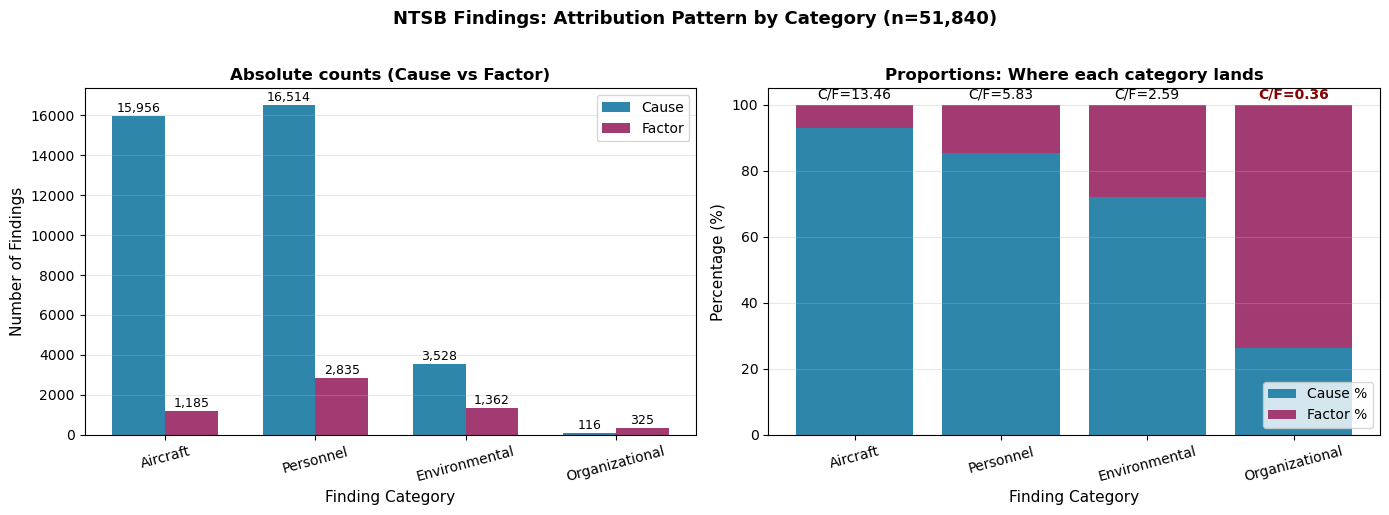


✅ Saved as: phase_a_attribution_pattern.png


In [8]:
# Phase A Visualization: Category x Cause/Factor
# Two panels: (1) absolute counts, (2) proportions

import matplotlib.pyplot as plt
import numpy as np

# Data from previous cell (manually entering for clarity)
categories = ['Aircraft', 'Personnel', 'Environmental', 'Organizational']
cause = [15956, 16514, 3528, 116]
factor = [1185, 2835, 1362, 325]

# Set up figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# === Panel 1: Absolute counts (grouped bar) ===
x = np.arange(len(categories))
width = 0.35

bars1 = axes[0].bar(x - width/2, cause, width, label='Cause', color='#2E86AB')
bars2 = axes[0].bar(x + width/2, factor, width, label='Factor', color='#A23B72')

axes[0].set_xlabel('Finding Category', fontsize=11)
axes[0].set_ylabel('Number of Findings', fontsize=11)
axes[0].set_title('Absolute counts (Cause vs Factor)', fontsize=12, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(categories, rotation=15)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2, h + 200,
                     f'{int(h):,}', ha='center', fontsize=9)

# === Panel 2: Proportions (stacked) ===
totals = [c + f for c, f in zip(cause, factor)]
cause_pct = [c/t*100 for c, t in zip(cause, totals)]
factor_pct = [f/t*100 for f, t in zip(factor, totals)]

bars_c = axes[1].bar(categories, cause_pct, label='Cause %', color='#2E86AB')
bars_f = axes[1].bar(categories, factor_pct, bottom=cause_pct, 
                      label='Factor %', color='#A23B72')

axes[1].set_xlabel('Finding Category', fontsize=11)
axes[1].set_ylabel('Percentage (%)', fontsize=11)
axes[1].set_title('Proportions: Where each category lands', fontsize=12, fontweight='bold')
axes[1].set_xticklabels(categories, rotation=15)
axes[1].legend(loc='lower right')
axes[1].set_ylim(0, 105)
axes[1].grid(axis='y', alpha=0.3)

# Add C/F ratio as annotation on each bar
ratios = [c/f for c, f in zip(cause, factor)]
for i, ratio in enumerate(ratios):
    color = 'darkred' if ratio < 1 else 'black'
    weight = 'bold' if ratio < 1 else 'normal'
    axes[1].text(i, 102, f'C/F={ratio:.2f}', ha='center', 
                 fontsize=10, color=color, fontweight=weight)

# Big title
fig.suptitle('NTSB Findings: Attribution Pattern by Category (n=51,840)',
             fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('phase_a_attribution_pattern.png', dpi=200, bbox_inches='tight')
plt.show()

print("\n✅ Saved as: phase_a_attribution_pattern.png")

In [9]:
# Phase A — Statistical test
# Chi-square test of independence + standardized residuals
# Question: Is the category-by-Cause/Factor pattern statistically significant?

from scipy.stats import chi2_contingency
import numpy as np

# Use the crosstab from previous cell
# (re-create here so this cell is self-contained)
import pandas as pd
import pyodbc

mdb_path = r"C:\Users\user\Desktop\avall.mdb"
conn_str = (
    r"DRIVER={Microsoft Access Driver (*.mdb, *.accdb)};"
    rf"DBQ={mdb_path};"
)
conn = pyodbc.connect(conn_str)
df = pd.read_sql("""
    SELECT category_no, Cause_Factor 
    FROM Findings 
    WHERE Cause_Factor IN ('C', 'F')
""", conn)
conn.close()

category_names = {'01': 'Aircraft', '02': 'Personnel', 
                  '03': 'Environmental', '04': 'Organizational'}
df['category_name'] = df['category_no'].map(category_names)
df = df.dropna(subset=['category_name'])

# Build the contingency table (only C and F, drop blanks)
crosstab = pd.crosstab(df['category_name'], df['Cause_Factor'])
print("Observed counts:")
print(crosstab)
print()

# === Chi-square test ===
chi2, p_value, dof, expected = chi2_contingency(crosstab)

print(f"Chi-square statistic: {chi2:.2f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p_value:.2e}")
print()

# Interpret
if p_value < 0.001:
    print("✅ Highly significant (p < 0.001)")
    print("   → The category × Cause/Factor association is NOT random.")
elif p_value < 0.05:
    print("✅ Significant (p < 0.05)")
else:
    print("❌ Not significant — pattern could be random.")
print()

# === Effect size: Cramér's V ===
n = crosstab.values.sum()
min_dim = min(crosstab.shape) - 1
cramers_v = np.sqrt(chi2 / (n * min_dim))
print(f"Cramér's V (effect size): {cramers_v:.3f}")
if cramers_v < 0.1:
    interp = "negligible"
elif cramers_v < 0.3:
    interp = "weak"
elif cramers_v < 0.5:
    interp = "moderate"
else:
    interp = "strong"
print(f"   → Effect size is {interp}.")
print()

# === Standardized residuals ===
# (observed - expected) / sqrt(expected)
# |z| > 1.96 → significantly different from expected at p<0.05
# |z| > 2.58 → significant at p<0.01
# |z| > 3.29 → significant at p<0.001

print("Standardized residuals (z-scores):")
print("  |z| > 1.96 = significant at p<0.05")
print("  |z| > 2.58 = significant at p<0.01")
print("  |z| > 3.29 = significant at p<0.001")
print()

residuals = (crosstab.values - expected) / np.sqrt(expected)
residuals_df = pd.DataFrame(residuals, 
                             index=crosstab.index, 
                             columns=crosstab.columns)
print(residuals_df.round(2))
print()

# Interpret each cell
print("Cell-by-cell interpretation:")
for cat in crosstab.index:
    for cf in crosstab.columns:
        z = residuals_df.loc[cat, cf]
        direction = "MORE" if z > 0 else "LESS"
        if abs(z) > 3.29:
            sig = "p<0.001"
        elif abs(z) > 2.58:
            sig = "p<0.01"
        elif abs(z) > 1.96:
            sig = "p<0.05"
        else:
            sig = "n.s."
        print(f"  {cat:15s} × {cf}: z={z:>6.2f} → {direction} than expected ({sig})")

C:\Users\user\AppData\Local\Temp\ipykernel_11516\3004353153.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("""


Observed counts:
Cause_Factor        C     F
category_name              
Aircraft        15956  1185
Environmental    3528  1362
Organizational    116   325
Personnel       16514  2835

Chi-square statistic: 2863.02
Degrees of freedom: 3
p-value: 0.00e+00

✅ Highly significant (p < 0.001)
   → The category × Cause/Factor association is NOT random.

Cramér's V (effect size): 0.262
   → Effect size is weak.

Standardized residuals (z-scores):
  |z| > 1.96 = significant at p<0.05
  |z| > 2.58 = significant at p<0.01
  |z| > 3.29 = significant at p<0.001

Cause_Factor        C      F
category_name               
Aircraft         9.49 -23.86
Environmental  -10.69  26.89
Organizational -13.57  34.14
Personnel       -1.51   3.79

Cell-by-cell interpretation:
  Aircraft        × C: z=  9.49 → MORE than expected (p<0.001)
  Aircraft        × F: z=-23.86 → LESS than expected (p<0.001)
  Environmental   × C: z=-10.69 → LESS than expected (p<0.001)
  Environmental   × F: z= 26.89 → MORE than expec

In [10]:
# Phase A — Step 4: Temporal trend
# Question: Is the convergence pattern strengthening or weakening over time?

import pandas as pd
import pyodbc

mdb_path = r"C:\Users\user\Desktop\avall.mdb"
conn_str = (
    r"DRIVER={Microsoft Access Driver (*.mdb, *.accdb)};"
    rf"DBQ={mdb_path};"
)
conn = pyodbc.connect(conn_str)

# Get findings + event date (we need to join with events table for the year)
# events table has ev_id and ev_date
df = pd.read_sql("""
    SELECT 
        f.category_no, 
        f.Cause_Factor,
        e.ev_date
    FROM Findings f
    INNER JOIN events e ON f.ev_id = e.ev_id
    WHERE f.Cause_Factor IN ('C', 'F')
""", conn)
conn.close()

print(f"Total findings with event date: {len(df):,}")
print(f"Date range: {df['ev_date'].min()} to {df['ev_date'].max()}")
print()

# Extract year
df['year'] = pd.to_datetime(df['ev_date']).dt.year

# Map category names
category_names = {'01': 'Aircraft', '02': 'Personnel', 
                  '03': 'Environmental', '04': 'Organizational'}
df['category_name'] = df['category_no'].map(category_names)
df = df.dropna(subset=['category_name'])

# Build year × category × C/F summary
yearly = df.groupby(['year', 'category_name', 'Cause_Factor']).size().unstack(fill_value=0)
yearly['ratio_C_to_F'] = yearly['C'] / yearly['F'].replace(0, pd.NA)
yearly = yearly.reset_index()

# Show count per year (just to confirm we have data)
print("Findings per year (last 10 years):")
year_counts = df.groupby('year').size()
print(year_counts.tail(10))
print()

# Show average ratio by 5-year buckets, per category
print("\n=== C/F ratio over time by category (5-year averages) ===")
df['year_bucket'] = (df['year'] // 5) * 5  # 1980, 1985, 1990, ...

bucket_summary = df.groupby(['year_bucket', 'category_name', 'Cause_Factor']).size().unstack(fill_value=0)
bucket_summary['n_total'] = bucket_summary['C'] + bucket_summary['F']
bucket_summary['ratio_C_F'] = bucket_summary['C'] / bucket_summary['F'].replace(0, pd.NA)
bucket_summary = bucket_summary.reset_index()

# Pivot for readability
pivot = bucket_summary.pivot(index='year_bucket', columns='category_name', values='ratio_C_F')
print(pivot.round(2))

C:\Users\user\AppData\Local\Temp\ipykernel_11516\1399560086.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("""


Total findings with event date: 43,525
Date range: 2008-01-01 00:00:00 to 2020-09-20 00:00:00

Findings per year (last 10 years):
year
2011    3533
2012    3658
2013    3213
2014    3413
2015    3410
2016    3534
2017    3421
2018    3226
2019    2532
2020    1049
dtype: int64


=== C/F ratio over time by category (5-year averages) ===
category_name  Aircraft  Environmental  Organizational  Personnel
year_bucket                                                      
2005               9.40           0.51            0.34       4.88
2010              12.50           3.37            0.33       5.44
2015              17.55           9.67            0.42       6.62
2020              46.25           6.12            0.00      12.61


In [11]:
# Phase A — Step 5: Robustness check on temporal trend
# Show counts per cell, not just ratios

bucket_with_n = df.groupby(['year_bucket', 'category_name', 'Cause_Factor']).size().unstack(fill_value=0)
bucket_with_n['n'] = bucket_with_n['C'] + bucket_with_n['F']
bucket_with_n['ratio_C_F'] = bucket_with_n['C'] / bucket_with_n['F'].replace(0, pd.NA)
bucket_with_n = bucket_with_n.reset_index()

print("=== Detailed counts per year-bucket × category ===\n")
for bucket in sorted(df['year_bucket'].unique()):
    print(f"--- {int(bucket)}-{int(bucket)+4} ---")
    sub = bucket_with_n[bucket_with_n['year_bucket'] == bucket]
    for _, row in sub.iterrows():
        cat = row['category_name']
        c, f, n = int(row['C']), int(row['F']), int(row['n'])
        ratio = row['ratio_C_F']
        ratio_str = f"{ratio:.2f}" if pd.notna(ratio) else "N/A"
        flag = "⚠️ SMALL" if n < 30 else ""
        print(f"  {cat:15s}: C={c:>5}  F={f:>5}  n={n:>5}  C/F={ratio_str}  {flag}")
    print()

=== Detailed counts per year-bucket × category ===

--- 2005-2009 ---
  Aircraft       : C= 2781  F=  296  n= 3077  C/F=9.40  
  Environmental  : C=  414  F=  817  n= 1231  C/F=0.51  
  Organizational : C=   23  F=   67  n=   90  C/F=0.34  
  Personnel      : C= 2647  F=  542  n= 3189  C/F=4.88  

--- 2010-2014 ---
  Aircraft       : C= 6576  F=  526  n= 7102  C/F=12.50  
  Environmental  : C= 1105  F=  328  n= 1433  C/F=3.37  
  Organizational : C=   53  F=  159  n=  212  C/F=0.33  
  Personnel      : C= 7023  F= 1292  n= 8315  C/F=5.44  

--- 2015-2019 ---
  Aircraft       : C= 6229  F=  355  n= 6584  C/F=17.55  
  Environmental  : C= 1856  F=  192  n= 2048  C/F=9.67  
  Organizational : C=   40  F=   96  n=  136  C/F=0.42  
  Personnel      : C= 6390  F=  965  n= 7355  C/F=6.62  

--- 2020-2024 ---
  Aircraft       : C=  370  F=    8  n=  378  C/F=46.25  
  Environmental  : C=  153  F=   25  n=  178  C/F=6.12  
  Organizational : C=    0  F=    3  n=    3  C/F=0.00  ⚠️ SMALL
  Perso

C:\Users\user\AppData\Local\Temp\ipykernel_11516\1891045705.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("""


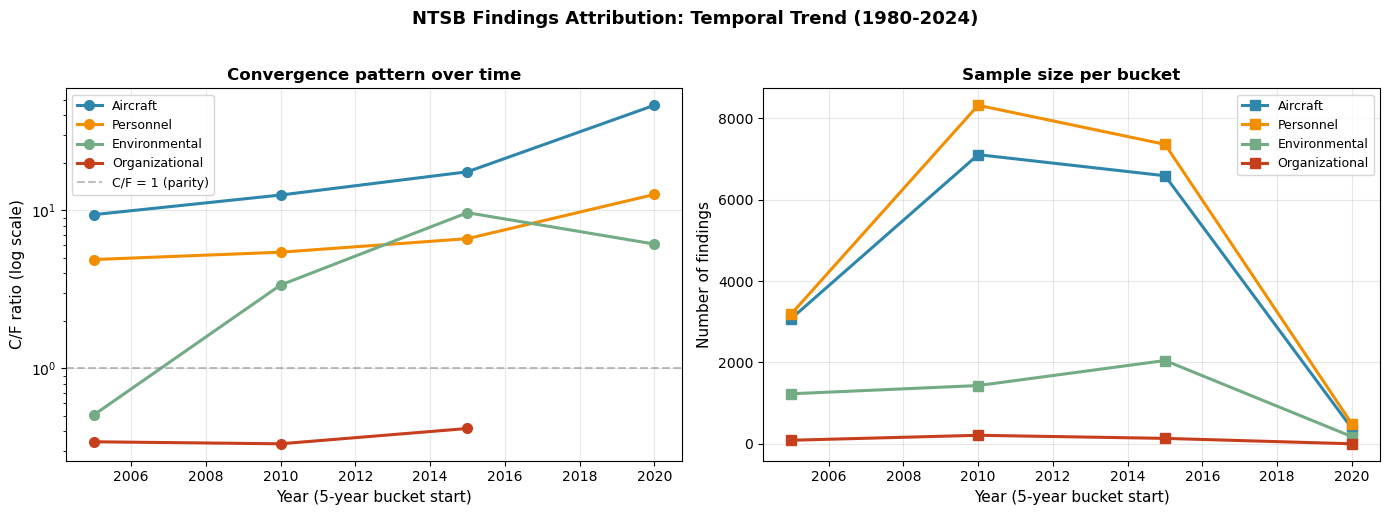

Saved: phase_a_temporal_trend.png


In [13]:
# Phase A — Step 5: Visualize C/F ratio over time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyodbc

mdb_path = r"C:\Users\user\Desktop\avall.mdb"
conn_str = (
    r"DRIVER={Microsoft Access Driver (*.mdb, *.accdb)};"
    rf"DBQ={mdb_path};"
)
conn = pyodbc.connect(conn_str)
df = pd.read_sql("""
    SELECT f.category_no, f.Cause_Factor, e.ev_date
    FROM Findings f
    INNER JOIN events e ON f.ev_id = e.ev_id
    WHERE f.Cause_Factor IN ('C', 'F')
""", conn)
conn.close()

df['year'] = pd.to_datetime(df['ev_date']).dt.year
df['year_bucket'] = (df['year'] // 5) * 5
category_names = {'01': 'Aircraft', '02': 'Personnel', 
                  '03': 'Environmental', '04': 'Organizational'}
df['category_name'] = df['category_no'].map(category_names)
df = df.dropna(subset=['category_name'])

# Aggregate by 5-year bucket and category
agg = df.groupby(['year_bucket', 'category_name', 'Cause_Factor']).size().unstack(fill_value=0)
agg['ratio'] = agg['C'] / agg['F'].replace(0, pd.NA)
agg['n_total'] = agg['C'] + agg['F']
agg = agg.reset_index()

agg_filtered = agg[agg['n_total'] >= 20].copy()
pivot_ratio = agg_filtered.pivot(index='year_bucket', columns='category_name', values='ratio')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {'Aircraft': '#2E86AB', 'Personnel': '#F18F01', 
          'Environmental': '#73AB84', 'Organizational': '#C73E1D'}

for cat in ['Aircraft', 'Personnel', 'Environmental', 'Organizational']:
    if cat in pivot_ratio.columns:
        axes[0].plot(pivot_ratio.index, pivot_ratio[cat], 
                     marker='o', linewidth=2.2, markersize=7,
                     label=cat, color=colors[cat])

axes[0].axhline(y=1, color='gray', linestyle='--', alpha=0.5, label='C/F = 1 (parity)')
axes[0].set_yscale('log')
axes[0].set_xlabel('Year (5-year bucket start)', fontsize=11)
axes[0].set_ylabel('C/F ratio (log scale)', fontsize=11)
axes[0].set_title('Convergence pattern over time', fontsize=12, fontweight='bold')
axes[0].legend(loc='best', fontsize=9)
axes[0].grid(alpha=0.3)

pivot_n = agg.pivot(index='year_bucket', columns='category_name', values='n_total')
for cat in ['Aircraft', 'Personnel', 'Environmental', 'Organizational']:
    if cat in pivot_n.columns:
        axes[1].plot(pivot_n.index, pivot_n[cat],
                     marker='s', linewidth=2.2, markersize=7,
                     label=cat, color=colors[cat])

axes[1].set_xlabel('Year (5-year bucket start)', fontsize=11)
axes[1].set_ylabel('Number of findings', fontsize=11)
axes[1].set_title('Sample size per bucket', fontsize=12, fontweight='bold')
axes[1].legend(loc='best', fontsize=9)
axes[1].grid(alpha=0.3)

fig.suptitle('NTSB Findings Attribution: Temporal Trend (1980-2024)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('phase_a_temporal_trend.png', dpi=200, bbox_inches='tight')
plt.show()

print("Saved: phase_a_temporal_trend.png")

In [14]:
# Phase A — Step 6: Sub-category breakdown of Organizational findings
# Question: WHICH kinds of organizational issues get demoted to Factor most?

import pandas as pd
import pyodbc

mdb_path = r"C:\Users\user\Desktop\avall.mdb"
conn_str = (
    r"DRIVER={Microsoft Access Driver (*.mdb, *.accdb)};"
    rf"DBQ={mdb_path};"
)
conn = pyodbc.connect(conn_str)

# Get all Organizational findings (category 04) with full code + description
df = pd.read_sql("""
    SELECT 
        category_no,
        subcategory_no,
        section_no,
        finding_description,
        Cause_Factor
    FROM Findings
    WHERE category_no = '04'
      AND Cause_Factor IN ('C', 'F')
""", conn)
conn.close()

print(f"Total Organizational findings: {len(df):,}")
print()

# Sub-category breakdown
print("=== Subcategory level (04-XX) ===")
sub_crosstab = pd.crosstab(df['subcategory_no'], df['Cause_Factor'])
sub_crosstab['n_total'] = sub_crosstab['C'] + sub_crosstab['F']
sub_crosstab['ratio_C_F'] = sub_crosstab['C'] / sub_crosstab['F'].replace(0, pd.NA)
sub_crosstab = sub_crosstab.sort_values('n_total', ascending=False)

# Add description from the most common finding for each subcategory
sub_descriptions = {}
for sub in sub_crosstab.index:
    sample = df[df['subcategory_no'] == sub]['finding_description'].iloc[0]
    # Take just the first 80 chars
    sub_descriptions[sub] = sample[:80] if isinstance(sample, str) else ''

print(f"\n{'sub':>4}  {'C':>5}  {'F':>5}  {'n':>5}  {'C/F':>5}  description")
print("-" * 100)
for sub in sub_crosstab.index:
    c = sub_crosstab.loc[sub, 'C']
    f = sub_crosstab.loc[sub, 'F']
    n = sub_crosstab.loc[sub, 'n_total']
    r = sub_crosstab.loc[sub, 'ratio_C_F']
    r_str = f"{r:.2f}" if pd.notna(r) else "inf"
    desc = sub_descriptions.get(sub, '')
    print(f"  {sub}  {c:>5}  {f:>5}  {n:>5}  {r_str:>5}  {desc}")

print()
print("=== Section level (04-XX-YY): top 15 most common ===")
df['code'] = df['subcategory_no'].astype(str) + '-' + df['section_no'].astype(str)
section_crosstab = pd.crosstab(df['code'], df['Cause_Factor'])
section_crosstab['n_total'] = section_crosstab['C'] + section_crosstab['F']
section_crosstab['ratio_C_F'] = section_crosstab['C'] / section_crosstab['F'].replace(0, pd.NA)
section_crosstab = section_crosstab.sort_values('n_total', ascending=False).head(15)

# Get a representative description for each section
section_descriptions = {}
for code in section_crosstab.index:
    sub, sec = code.split('-')
    sample = df[(df['subcategory_no'] == sub) & (df['section_no'] == sec)]['finding_description'].iloc[0]
    section_descriptions[code] = sample[:90] if isinstance(sample, str) else ''

print(f"\n{'code':>7}  {'C':>4}  {'F':>4}  {'n':>4}  {'C/F':>5}  description")
print("-" * 110)
for code in section_crosstab.index:
    c = section_crosstab.loc[code, 'C']
    f = section_crosstab.loc[code, 'F']
    n = section_crosstab.loc[code, 'n_total']
    r = section_crosstab.loc[code, 'ratio_C_F']
    r_str = f"{r:.2f}" if pd.notna(r) else "inf"
    desc = section_descriptions.get(code, '')
    print(f"  {code:>7}  {c:>4}  {f:>4}  {n:>4}  {r_str:>5}  {desc}")

Total Organizational findings: 441

=== Subcategory level (04-XX) ===

 sub      C      F      n    C/F  description
----------------------------------------------------------------------------------------------------
  03     33    142    175   0.23  Organizational issues-Support/oversight/monitoring-Training-Emergency proc train
  02     40    112    152   0.36  Organizational issues-Management-Policy/procedure-Availability of policy/proc-Ma
  01     43     71    114   0.61  Organizational issues-Development-Design-Task design-Manufacturer

=== Section level (04-XX-YY): top 15 most common ===

   code     C     F     n    C/F  description
--------------------------------------------------------------------------------------------------------------
    02-10    20    84   104   0.24  Organizational issues-Management-Policy/procedure-Availability of policy/proc-Manufacturer
    03-20    24    68    92   0.35  Organizational issues-Support/oversight/monitoring-Oversight-Oversight of ope

C:\Users\user\AppData\Local\Temp\ipykernel_11516\3700320417.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("""


In [15]:
# Step 7: What ARE those 5 findings under code 03-40?
# (Organizational - Support/oversight/monitoring - Enforcement - Regulatory requirements - FAA)

import pandas as pd
import pyodbc

mdb_path = r"C:\Users\user\Desktop\avall.mdb"
conn_str = (
    r"DRIVER={Microsoft Access Driver (*.mdb, *.accdb)};"
    rf"DBQ={mdb_path};"
)
conn = pyodbc.connect(conn_str)

# Pull all 5 findings under 03-40
df = pd.read_sql("""
    SELECT 
        f.ev_id,
        f.subcategory_no,
        f.section_no,
        f.subsection_no,
        f.modifier_no,
        f.finding_description,
        f.Cause_Factor,
        e.ev_date,
        e.ev_state,
        e.ev_country,
        e.ev_highest_injury
    FROM Findings f
    INNER JOIN events e ON f.ev_id = e.ev_id
    WHERE f.category_no = '04'
      AND f.subcategory_no = '03'
      AND f.section_no = '40'
""", conn)
conn.close()

print(f"Total findings under 04-03-40 (FAA enforcement): {len(df)}")
print()
print("Each finding in detail:")
print("=" * 100)
for i, row in df.iterrows():
    print(f"\n[{i+1}] Event: {row['ev_id']} | Date: {row['ev_date']}")
    print(f"    Cause/Factor: {row['Cause_Factor']}")
    print(f"    Highest injury: {row['ev_highest_injury']}")
    print(f"    State/Country: {row['ev_state']}, {row['ev_country']}")
    print(f"    Description: {row['finding_description']}")

Total findings under 04-03-40 (FAA enforcement): 15

Each finding in detail:

[1] Event: 20080602X00763 | Date: 2008-05-15 00:00:00
    Cause/Factor: F
    Highest injury: NONE
    State/Country: CA, USA
    Description: Organizational issues-Support/oversight/monitoring-Enforcement-Regulatory requirements-FAA/Regulator - F

[2] Event: 20080806X01166 | Date: 2008-07-31 00:00:00
    Cause/Factor: F
    Highest injury: FATL
    State/Country: MN, USA
    Description: Organizational issues-Support/oversight/monitoring-Enforcement-Regulatory requirements-FAA/Regulator

[3] Event: 20090104X12037 | Date: 2009-01-04 00:00:00
    Cause/Factor: F
    Highest injury: FATL
    State/Country: LA, USA
    Description: Organizational issues-Support/oversight/monitoring-Enforcement-Regulatory requirements-FAA/Regulator

[4] Event: 20160803X34325 | Date: 2016-08-03 00:00:00
    Cause/Factor:  
    Highest injury: FATL
    State/Country: AZ, USA
    Description: Organizational issues-Support/oversight/

C:\Users\user\AppData\Local\Temp\ipykernel_11516\3751031627.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("""


In [16]:
# Step 8: When does NTSB refuse to classify (None / blank)?
# Question: Is the abstention pattern systematic or random?

import pandas as pd
import pyodbc

mdb_path = r"C:\Users\user\Desktop\avall.mdb"
conn_str = (
    r"DRIVER={Microsoft Access Driver (*.mdb, *.accdb)};"
    rf"DBQ={mdb_path};"
)
conn = pyodbc.connect(conn_str)

# Pull ALL findings (including unclassified) with event date
df = pd.read_sql("""
    SELECT 
        f.category_no,
        f.Cause_Factor,
        e.ev_date
    FROM Findings f
    INNER JOIN events e ON f.ev_id = e.ev_id
""", conn)
conn.close()

# Classify Cause_Factor into 3 states
def classify_cf(val):
    if val == 'C':
        return 'Cause'
    elif val == 'F':
        return 'Factor'
    elif val is None or (isinstance(val, str) and val.strip() == ''):
        return 'Unclassified'
    else:
        return 'Other'

df['cf_status'] = df['Cause_Factor'].apply(classify_cf)
df['year'] = pd.to_datetime(df['ev_date']).dt.year

print(f"Total findings: {len(df):,}")
print()
print("Distribution of classification states:")
print(df['cf_status'].value_counts())
print()

# Year-by-year proportion of Unclassified
yearly = df.groupby(['year', 'cf_status']).size().unstack(fill_value=0)
yearly['total'] = yearly.sum(axis=1)
for col in ['Cause', 'Factor', 'Unclassified']:
    if col in yearly.columns:
        yearly[f'{col}_pct'] = yearly[col] / yearly['total'] * 100

print("=== Yearly: % Unclassified (last 20 years) ===")
print(yearly[['total', 'Cause_pct', 'Factor_pct', 'Unclassified_pct']].tail(20).round(1))

C:\Users\user\AppData\Local\Temp\ipykernel_11516\4032235305.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("""


Total findings: 71,114

Distribution of classification states:
cf_status
Cause           37767
Unclassified    27589
Factor           5758
Name: count, dtype: int64

=== Yearly: % Unclassified (last 20 years) ===
cf_status  total  Cause_pct  Factor_pct  Unclassified_pct
year                                                     
2008        5020       58.7        24.1              17.2
2009        4634       70.1        11.2              18.8
2010        4192       72.6         9.4              18.1
2011        4466       72.3        10.1              17.6
2012        4494       72.8        12.3              14.9
2013        3928       73.0        12.0              15.0
2014        4363       71.0        10.6              18.4
2015        4262       73.4        10.3              16.3
2016        4577       71.2         8.9              19.9
2017        4546       71.1         6.9              22.0
2018        4449       68.4         6.8              24.9
2019        4192       57.7      

In [17]:
# Phase A — Step 9: Does fatality severity affect attribution?
# Hypothesis: When people die, do organizational issues get demoted MORE?
# Constrained to 2008-2018 (clean coding period)

import pandas as pd
import pyodbc

mdb_path = r"C:\Users\user\Desktop\avall.mdb"
conn_str = (
    r"DRIVER={Microsoft Access Driver (*.mdb, *.accdb)};"
    rf"DBQ={mdb_path};"
)
conn = pyodbc.connect(conn_str)

# Findings + injury severity, restricted to clean coding years
df = pd.read_sql("""
    SELECT 
        f.category_no,
        f.Cause_Factor,
        e.ev_highest_injury,
        e.ev_date
    FROM Findings f
    INNER JOIN events e ON f.ev_id = e.ev_id
    WHERE f.Cause_Factor IN ('C', 'F')
      AND e.ev_highest_injury IS NOT NULL
""", conn)
conn.close()

df['year'] = pd.to_datetime(df['ev_date']).dt.year
df = df[(df['year'] >= 2008) & (df['year'] <= 2018)].copy()

print(f"Total findings (2008-2018, with injury data): {len(df):,}")
print()
print("Injury severity distribution:")
print(df['ev_highest_injury'].value_counts())
print()

# Map injury codes
injury_map = {
    'NONE': '1_None',
    'MINR': '2_Minor',
    'SERS': '3_Serious',
    'FATL': '4_Fatal'
}
df['injury_severity'] = df['ev_highest_injury'].map(injury_map)
df = df.dropna(subset=['injury_severity'])

# Map category names
category_names = {'01': 'Aircraft', '02': 'Personnel', 
                  '03': 'Environmental', '04': 'Organizational'}
df['category_name'] = df['category_no'].map(category_names)
df = df.dropna(subset=['category_name'])

print("\n=== C/F ratio by category × injury severity ===\n")
for cat in ['Aircraft', 'Personnel', 'Environmental', 'Organizational']:
    print(f"--- {cat} ---")
    sub = df[df['category_name'] == cat]
    crosstab = pd.crosstab(sub['injury_severity'], sub['Cause_Factor'])
    crosstab['n_total'] = crosstab.sum(axis=1)
    crosstab['ratio_C_F'] = crosstab['C'] / crosstab['F'].replace(0, pd.NA)
    crosstab = crosstab.sort_index()
    
    for sev in crosstab.index:
        c = crosstab.loc[sev, 'C']
        f = crosstab.loc[sev, 'F']
        n = crosstab.loc[sev, 'n_total']
        r = crosstab.loc[sev, 'ratio_C_F']
        r_str = f"{r:.2f}" if pd.notna(r) else "inf"
        print(f"  {sev:12s}: C={c:>5,}  F={f:>4}  n={n:>5,}  C/F={r_str}")
    print()

C:\Users\user\AppData\Local\Temp\ipykernel_11516\910845334.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("""


Total findings (2008-2018, with injury data): 39,712

Injury severity distribution:
ev_highest_injury
NONE    20239
FATL     8973
MINR     5781
SERS     4719
Name: count, dtype: int64


=== C/F ratio by category × injury severity ===

--- Aircraft ---
  1_None      : C=8,114  F= 461  n=8,575  C/F=17.60
  2_Minor     : C=2,280  F= 180  n=2,460  C/F=12.67
  3_Serious   : C=1,632  F= 177  n=1,809  C/F=9.22
  4_Fatal     : C=2,620  F= 318  n=2,938  C/F=8.24

--- Personnel ---
  1_None      : C=7,804  F= 982  n=8,786  C/F=7.95
  2_Minor     : C=2,083  F= 325  n=2,408  C/F=6.41
  3_Serious   : C=1,715  F= 330  n=2,045  C/F=5.20
  4_Fatal     : C=3,404  F=1037  n=4,441  C/F=3.28

--- Environmental ---
  1_None      : C=1,360  F= 679  n=2,039  C/F=2.00
  2_Minor     : C=  347  F= 208  n=  555  C/F=1.67
  3_Serious   : C=  459  F= 142  n=  601  C/F=3.23
  4_Fatal     : C=  742  F= 281  n=1,023  C/F=2.64

--- Organizational ---
  1_None      : C=   50  F= 115  n=  165  C/F=0.43
  2_Minor     : C

In [18]:
# Phase A — Step 10: Event-level analysis
# Question: Within a single accident, how is attribution distributed?
# Constrained to 2008-2018 (clean coding period)

import pandas as pd
import pyodbc

mdb_path = r"C:\Users\user\Desktop\avall.mdb"
conn_str = (
    r"DRIVER={Microsoft Access Driver (*.mdb, *.accdb)};"
    rf"DBQ={mdb_path};"
)
conn = pyodbc.connect(conn_str)

df = pd.read_sql("""
    SELECT 
        f.ev_id,
        f.category_no,
        f.Cause_Factor,
        e.ev_date,
        e.ev_highest_injury
    FROM Findings f
    INNER JOIN events e ON f.ev_id = e.ev_id
    WHERE f.Cause_Factor IN ('C', 'F')
""", conn)
conn.close()

df['year'] = pd.to_datetime(df['ev_date']).dt.year
df = df[(df['year'] >= 2008) & (df['year'] <= 2018)].copy()

category_names = {'01': 'Aircraft', '02': 'Personnel', 
                  '03': 'Environmental', '04': 'Organizational'}
df['category_name'] = df['category_no'].map(category_names)
df = df.dropna(subset=['category_name'])

# Per-event summary
print(f"Total findings: {len(df):,}")
print(f"Total unique events: {df['ev_id'].nunique():,}")
print(f"Mean findings per event: {len(df) / df['ev_id'].nunique():.2f}")
print()

# How many findings per event distribution
findings_per_event = df.groupby('ev_id').size()
print("Findings per event (distribution):")
print(f"  Min: {findings_per_event.min()}")
print(f"  Median: {findings_per_event.median()}")
print(f"  Mean: {findings_per_event.mean():.2f}")
print(f"  Max: {findings_per_event.max()}")
print()

# === Key analysis: Among events with at least one Organizational finding,
#     what proportion of that Organizational finding is coded as Cause? ===

# For each event, compute:
#   - n_org_findings: how many organizational findings
#   - n_org_cause: how many of those are Cause
#   - has_org: does this event have any organizational finding

event_summary = df.groupby('ev_id').apply(
    lambda g: pd.Series({
        'total_findings': len(g),
        'has_org': (g['category_name'] == 'Organizational').any(),
        'n_org': (g['category_name'] == 'Organizational').sum(),
        'n_org_cause': ((g['category_name'] == 'Organizational') & 
                        (g['Cause_Factor'] == 'C')).sum(),
        'n_personnel': (g['category_name'] == 'Personnel').sum(),
        'n_aircraft': (g['category_name'] == 'Aircraft').sum(),
        'highest_injury': g['ev_highest_injury'].iloc[0],
    }), 
    include_groups=False
).reset_index()

n_events_total = len(event_summary)
n_events_with_org = event_summary['has_org'].sum()

print(f"=== Event-level findings ===")
print(f"Total events (2008-2018): {n_events_total:,}")
print(f"Events with at least one Organizational finding: {n_events_with_org:,}")
print(f"  → That's only {n_events_with_org/n_events_total*100:.1f}% of all events")
print()

# Among those events, how is org attribution distributed?
events_with_org = event_summary[event_summary['has_org']].copy()
events_with_org['org_cause_ratio'] = events_with_org['n_org_cause'] / events_with_org['n_org']

print(f"Among the {n_events_with_org:,} events with an Organizational finding:")
print(f"  Mean number of Organizational findings per event: {events_with_org['n_org'].mean():.2f}")
print(f"  Mean number of Total findings per event: {events_with_org['total_findings'].mean():.2f}")
print()

# What proportion of these events have Org as Cause (at least one)?
events_with_org['any_org_cause'] = events_with_org['n_org_cause'] > 0
print(f"  Events where AT LEAST ONE Org finding is Cause: {events_with_org['any_org_cause'].sum():,} ({events_with_org['any_org_cause'].mean()*100:.1f}%)")
print(f"  Events where ALL Org findings are Factor: {(~events_with_org['any_org_cause']).sum():,} ({(~events_with_org['any_org_cause']).mean()*100:.1f}%)")
print()

# Cross-tabulate by injury severity
print("=== Org-as-cause rate by accident severity ===")
for sev in ['NONE', 'MINR', 'SERS', 'FATL']:
    sub = events_with_org[events_with_org['highest_injury'] == sev]
    if len(sub) > 0:
        rate = sub['any_org_cause'].mean() * 100
        print(f"  {sev:5s}: {len(sub):>4,} events with Org finding | {sub['any_org_cause'].sum():>3} ({rate:.1f}%) have Org as Cause")

C:\Users\user\AppData\Local\Temp\ipykernel_11516\1294291257.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("""


Total findings: 38,240
Total unique events: 14,940
Mean findings per event: 2.56

Findings per event (distribution):
  Min: 1
  Median: 2.0
  Mean: 2.56
  Max: 15

=== Event-level findings ===
Total events (2008-2018): 14,940
Events with at least one Organizational finding: 298
  → That's only 2.0% of all events

Among the 298 events with an Organizational finding:
  Mean number of Organizational findings per event: 1.43
  Mean number of Total findings per event: 4.50

  Events where AT LEAST ONE Org finding is Cause: 87 (29.2%)
  Events where ALL Org findings are Factor: 211 (70.8%)

=== Org-as-cause rate by accident severity ===
  NONE :  130 events with Org finding |  48 (36.9%) have Org as Cause
  MINR :   31 events with Org finding |   9 (29.0%) have Org as Cause
  SERS :   30 events with Org finding |   4 (13.3%) have Org as Cause
  FATL :   92 events with Org finding |  22 (23.9%) have Org as Cause


C:\Users\user\AppData\Local\Temp\ipykernel_11516\1027601376.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("""
C:\Users\user\AppData\Local\Temp\ipykernel_11516\1027601376.py:67: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  bars = ax.barh(range(len(agg)), agg['ratio'].fillna(0), color=colors, edgecolor='white')
C:\Users\user\AppData\Local\Temp\ipykernel_11516\1027601376.py:90: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_op

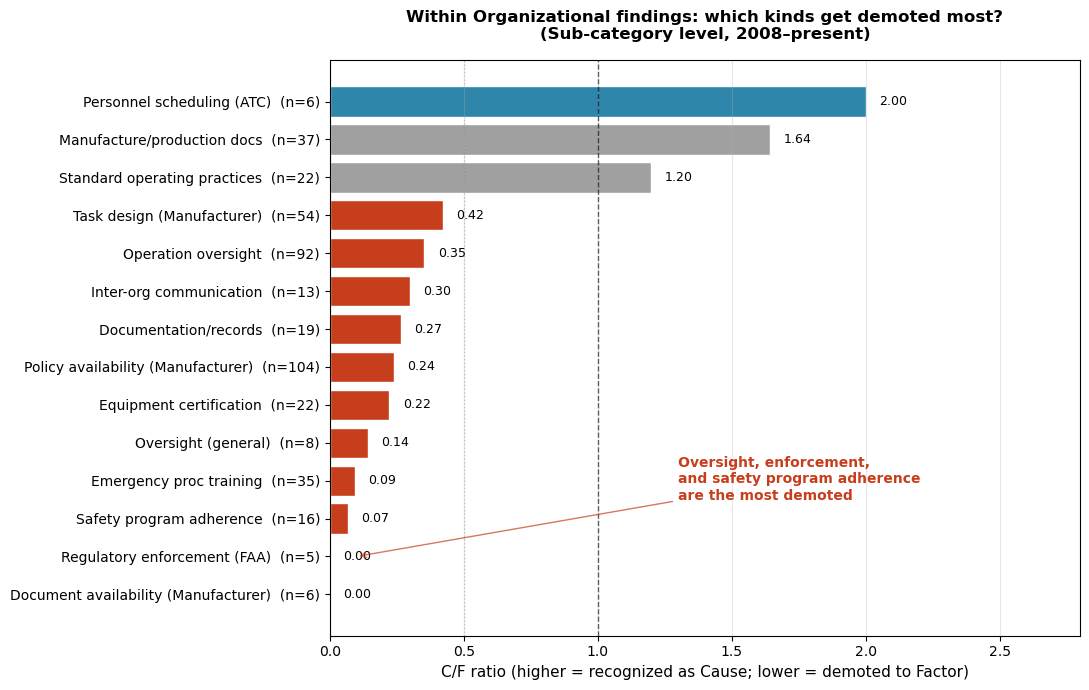

Saved: figure_3_subcategory_demotion.png


In [19]:
# Figure 3: Sub-category breakdown of Organizational findings
# Question: WHICH organizational issues get most demoted?

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyodbc

mdb_path = r"C:\Users\user\Desktop\avall.mdb"
conn_str = (
    r"DRIVER={Microsoft Access Driver (*.mdb, *.accdb)};"
    rf"DBQ={mdb_path};"
)
conn = pyodbc.connect(conn_str)
df = pd.read_sql("""
    SELECT subcategory_no, section_no, Cause_Factor
    FROM Findings
    WHERE category_no = '04'
      AND Cause_Factor IN ('C', 'F')
""", conn)
conn.close()

# Build subcategory + section code (e.g. "02-10")
df['code'] = df['subcategory_no'].astype(str) + '-' + df['section_no'].astype(str)

# Manual labels (short, readable)
section_labels = {
    '01-10': 'Task design (Manufacturer)',
    '01-20': 'Equipment certification',
    '01-30': 'Manufacture/production docs',
    '02-10': 'Policy availability (Manufacturer)',
    '02-20': 'Document availability (Manufacturer)',
    '02-30': 'Personnel scheduling (ATC)',
    '02-40': 'Standard operating practices',
    '02-50': 'Inter-org communication',
    '03-00': 'Oversight (general)',
    '03-10': 'Emergency proc training',
    '03-20': 'Operation oversight',
    '03-30': 'Documentation/records',
    '03-40': 'Regulatory enforcement (FAA)',
    '03-50': 'Safety program adherence',
}

# Aggregate
agg = df.groupby('code')['Cause_Factor'].value_counts().unstack(fill_value=0)
agg['n_total'] = agg['C'] + agg['F']
agg['ratio'] = agg['C'] / agg['F'].replace(0, pd.NA)
agg = agg[agg['n_total'] >= 5].copy()  # filter very small samples
agg['label'] = agg.index.map(lambda x: section_labels.get(x, x))
agg = agg.sort_values('ratio')

# Plot — horizontal bar, sorted by C/F ratio
fig, ax = plt.subplots(figsize=(11, 7))

# Color: red if ratio < 1 (demoted), gray if ~1, blue if > 1 (recognized)
colors = []
for r in agg['ratio']:
    if pd.isna(r) or r < 0.5:
        colors.append('#C73E1D')  # strong demotion
    elif r < 1:
        colors.append('#E89A8A')  # moderate demotion
    elif r < 2:
        colors.append('#A0A0A0')  # roughly balanced
    else:
        colors.append('#2E86AB')  # recognized

bars = ax.barh(range(len(agg)), agg['ratio'].fillna(0), color=colors, edgecolor='white')

# Y-axis labels
labels_with_n = [f"{lbl}  (n={n})" for lbl, n in zip(agg['label'], agg['n_total'])]
ax.set_yticks(range(len(agg)))
ax.set_yticklabels(labels_with_n, fontsize=10)

# Vertical reference lines
ax.axvline(x=1, color='black', linestyle='--', alpha=0.6, linewidth=1, label='C/F = 1 (parity)')
ax.axvline(x=0.5, color='gray', linestyle=':', alpha=0.4, linewidth=1)

# Value labels on bars
for i, (r, n) in enumerate(zip(agg['ratio'], agg['n_total'])):
    if pd.notna(r):
        x_pos = r + 0.05
        ax.text(x_pos, i, f'{r:.2f}', va='center', fontsize=9)
    else:
        ax.text(0.05, i, '0.00', va='center', fontsize=9, color='darkred', fontweight='bold')

ax.set_xlabel('C/F ratio (higher = recognized as Cause; lower = demoted to Factor)', fontsize=11)
ax.set_title('Within Organizational findings: which kinds get demoted most?\n(Sub-category level, 2008–present)', 
             fontsize=12, fontweight='bold', pad=15)

ax.set_xlim(0, max(agg['ratio'].fillna(0).max(), 2.5) + 0.3)
ax.grid(axis='x', alpha=0.3)

# Annotation for the most demoted ones
ax.annotate('Oversight, enforcement,\nand safety program adherence\nare the most demoted',
            xy=(0.1, 1), xytext=(1.3, 2.5),
            fontsize=10, color='#C73E1D', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#C73E1D', alpha=0.7))

plt.tight_layout()
plt.savefig('figure_3_subcategory_demotion.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: figure_3_subcategory_demotion.png")

C:\Users\user\AppData\Local\Temp\ipykernel_11516\2734731824.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("""


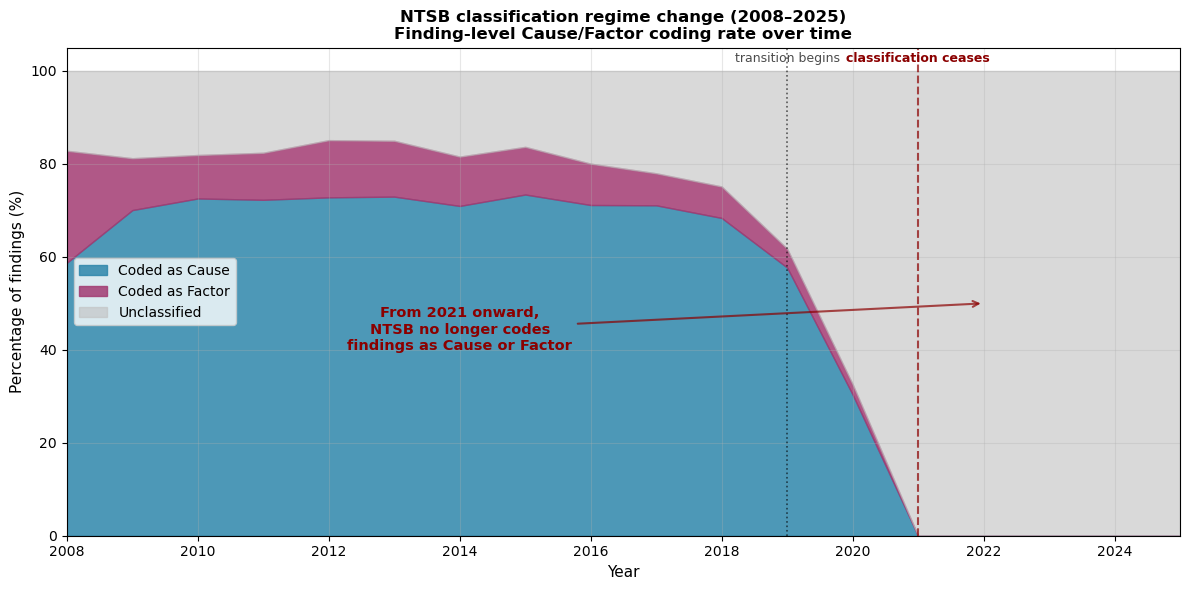

Saved: figure_4_classification_regime_change.png


In [20]:
# Figure 4: Classification rate over time
# The "NTSB stopped coding cause/factor in 2021" finding

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyodbc

mdb_path = r"C:\Users\user\Desktop\avall.mdb"
conn_str = (
    r"DRIVER={Microsoft Access Driver (*.mdb, *.accdb)};"
    rf"DBQ={mdb_path};"
)
conn = pyodbc.connect(conn_str)
df = pd.read_sql("""
    SELECT f.Cause_Factor, e.ev_date
    FROM Findings f
    INNER JOIN events e ON f.ev_id = e.ev_id
""", conn)
conn.close()

def classify_cf(val):
    if val == 'C':
        return 'Cause'
    elif val == 'F':
        return 'Factor'
    elif val is None or (isinstance(val, str) and val.strip() == ''):
        return 'Unclassified'
    else:
        return 'Other'

df['cf_status'] = df['Cause_Factor'].apply(classify_cf)
df['year'] = pd.to_datetime(df['ev_date']).dt.year
df = df[(df['year'] >= 2008) & (df['year'] <= 2025)].copy()

yearly = df.groupby(['year', 'cf_status']).size().unstack(fill_value=0)
yearly['total'] = yearly.sum(axis=1)
for col in ['Cause', 'Factor', 'Unclassified']:
    if col in yearly.columns:
        yearly[f'{col}_pct'] = yearly[col] / yearly['total'] * 100

# Plot — stacked area showing the regime change
fig, ax = plt.subplots(figsize=(12, 6))

years = yearly.index
cause_pct = yearly['Cause_pct']
factor_pct = yearly['Factor_pct']
unclassified_pct = yearly['Unclassified_pct']

ax.fill_between(years, 0, cause_pct, color='#2E86AB', alpha=0.85, label='Coded as Cause')
ax.fill_between(years, cause_pct, cause_pct + factor_pct, color='#A23B72', alpha=0.85, label='Coded as Factor')
ax.fill_between(years, cause_pct + factor_pct, 100, color='#C0C0C0', alpha=0.6, label='Unclassified')

# The transition zone — 2019-2020
ax.axvline(x=2019, color='black', linestyle=':', linewidth=1.2, alpha=0.6)
ax.axvline(x=2021, color='darkred', linestyle='--', linewidth=1.5, alpha=0.7)

ax.text(2019, 102, 'transition begins', ha='center', fontsize=9, color='black', alpha=0.7)
ax.text(2021, 102, 'classification ceases', ha='center', fontsize=9, color='darkred', fontweight='bold')

# Annotation arrow pointing at the cliff
ax.annotate('From 2021 onward,\nNTSB no longer codes\nfindings as Cause or Factor',
            xy=(2022, 50), xytext=(2014, 40),
            fontsize=10.5, color='darkred', fontweight='bold',
            ha='center',
            arrowprops=dict(arrowstyle='->', color='darkred', lw=1.5, alpha=0.7))

ax.set_xlim(2008, 2025)
ax.set_ylim(0, 105)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Percentage of findings (%)', fontsize=11)
ax.set_title('NTSB classification regime change (2008–2025)\nFinding-level Cause/Factor coding rate over time',
             fontsize=12, fontweight='bold')
ax.legend(loc='center left', fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figure_4_classification_regime_change.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: figure_4_classification_regime_change.png")

C:\Users\user\AppData\Local\Temp\ipykernel_11516\1870470428.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("""


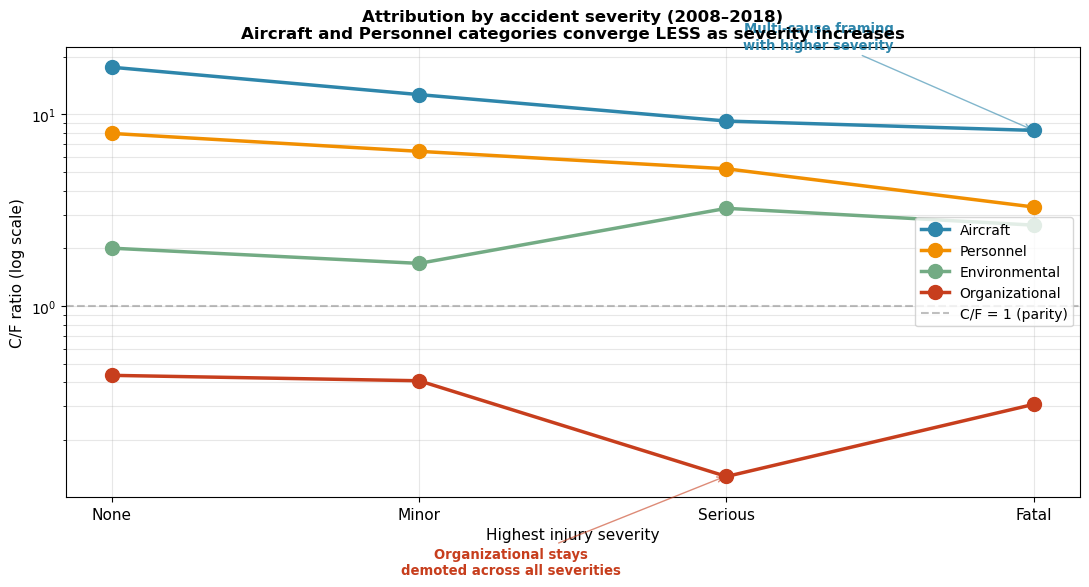

Saved: figure_5_severity_gradient.png


In [21]:
# Figure 5: Severity gradient
# Question: Does fatality affect attribution patterns?
# Constrained to 2008-2018 (clean coding period)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyodbc

mdb_path = r"C:\Users\user\Desktop\avall.mdb"
conn_str = (
    r"DRIVER={Microsoft Access Driver (*.mdb, *.accdb)};"
    rf"DBQ={mdb_path};"
)
conn = pyodbc.connect(conn_str)
df = pd.read_sql("""
    SELECT 
        f.category_no,
        f.Cause_Factor,
        e.ev_highest_injury,
        e.ev_date
    FROM Findings f
    INNER JOIN events e ON f.ev_id = e.ev_id
    WHERE f.Cause_Factor IN ('C', 'F')
      AND e.ev_highest_injury IS NOT NULL
""", conn)
conn.close()

df['year'] = pd.to_datetime(df['ev_date']).dt.year
df = df[(df['year'] >= 2008) & (df['year'] <= 2018)].copy()

category_names = {'01': 'Aircraft', '02': 'Personnel', 
                  '03': 'Environmental', '04': 'Organizational'}
df['category_name'] = df['category_no'].map(category_names)
df = df.dropna(subset=['category_name'])

# Order severity
severity_order = ['NONE', 'MINR', 'SERS', 'FATL']
severity_labels = {'NONE': 'None', 'MINR': 'Minor', 'SERS': 'Serious', 'FATL': 'Fatal'}

# Compute C/F ratio per category × severity
results = []
for cat in ['Aircraft', 'Personnel', 'Environmental', 'Organizational']:
    for sev in severity_order:
        sub = df[(df['category_name'] == cat) & (df['ev_highest_injury'] == sev)]
        c = (sub['Cause_Factor'] == 'C').sum()
        f = (sub['Cause_Factor'] == 'F').sum()
        ratio = c / f if f > 0 else float('nan')
        results.append({'category': cat, 'severity': sev, 'C': c, 'F': f, 
                        'n': c + f, 'ratio': ratio})
results_df = pd.DataFrame(results)

# Pivot for plot
pivot = results_df.pivot(index='severity', columns='category', values='ratio')
pivot = pivot.reindex(severity_order)
pivot.index = [severity_labels[s] for s in pivot.index]

# Plot — line plot showing ratio across severity
fig, ax = plt.subplots(figsize=(11, 6))

colors = {'Aircraft': '#2E86AB', 'Personnel': '#F18F01', 
          'Environmental': '#73AB84', 'Organizational': '#C73E1D'}

x = np.arange(len(severity_order))

for cat in ['Aircraft', 'Personnel', 'Environmental', 'Organizational']:
    ax.plot(x, pivot[cat], marker='o', linewidth=2.5, markersize=10,
            label=cat, color=colors[cat])

ax.axhline(y=1, color='gray', linestyle='--', alpha=0.5, label='C/F = 1 (parity)')

# Y-axis log scale to show all categories together
ax.set_yscale('log')
ax.set_xticks(x)
ax.set_xticklabels([severity_labels[s] for s in severity_order], fontsize=11)
ax.set_xlabel('Highest injury severity', fontsize=11)
ax.set_ylabel('C/F ratio (log scale)', fontsize=11)
ax.set_title('Attribution by accident severity (2008–2018)\n'
             'Aircraft and Personnel categories converge LESS as severity increases',
             fontsize=12, fontweight='bold')
ax.legend(loc='center right', fontsize=10)
ax.grid(alpha=0.3, which='both')

# Annotation: aircraft drops
ax.annotate('Multi-cause framing\nwith higher severity',
            xy=(3, 8.24), xytext=(2.3, 22),
            fontsize=9.5, color='#2E86AB', fontweight='bold', ha='center',
            arrowprops=dict(arrowstyle='->', color='#2E86AB', alpha=0.6))

# Annotation: organizational stays low
ax.annotate('Organizational stays\ndemoted across all severities',
            xy=(2, 0.13), xytext=(1.3, 0.04),
            fontsize=9.5, color='#C73E1D', fontweight='bold', ha='center',
            arrowprops=dict(arrowstyle='->', color='#C73E1D', alpha=0.6))

plt.tight_layout()
plt.savefig('figure_5_severity_gradient.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: figure_5_severity_gradient.png")

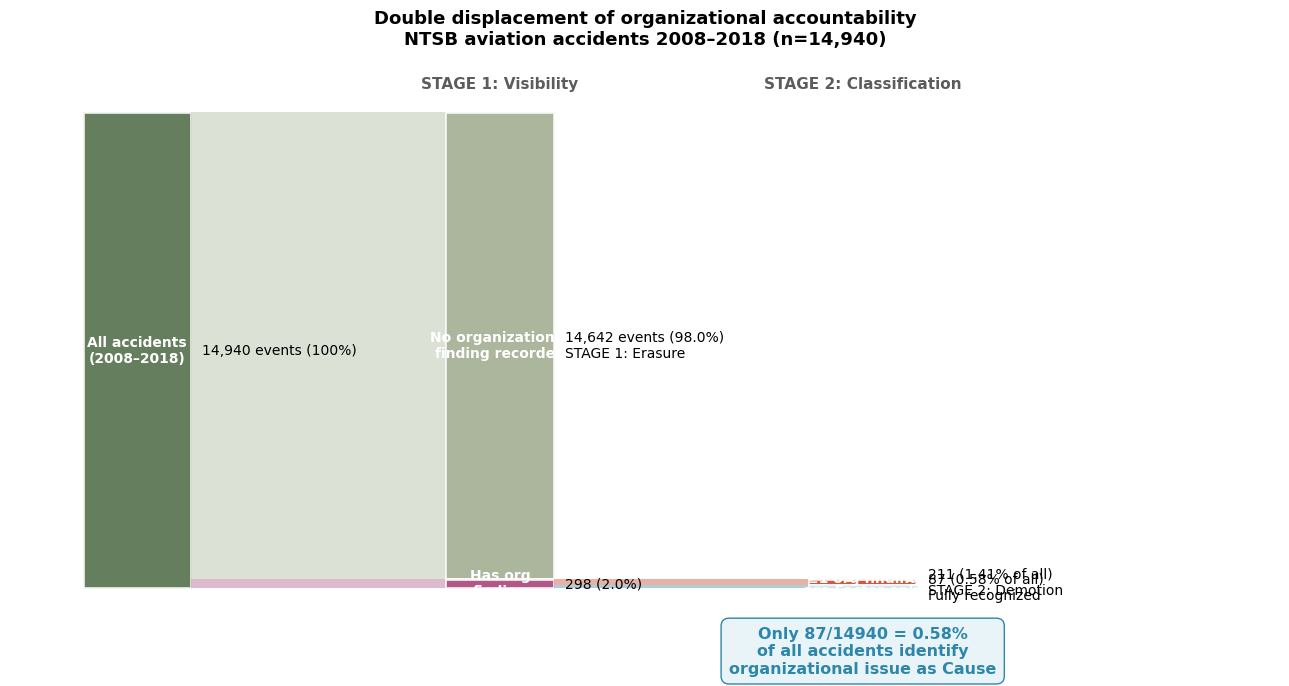

Saved: figure_6_double_displacement.png


In [22]:
# Figure 6: Double displacement of organizational accountability
# The "0.58%" finding visualized

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# The numbers
total_events = 14940
events_with_org = 298
events_org_factor_only = 211
events_org_with_cause = 87

events_no_org = total_events - events_with_org

fig, ax = plt.subplots(figsize=(13, 7))

# Layout: 3 columns
# Col 1 (left): all events
# Col 2 (middle): split into "no org" vs "with org"
# Col 3 (right): within "with org", split into "factor only" vs "any cause"

# Background and color settings
col1_x = 0.5
col2_x = 5.5
col3_x = 10.5
bar_width = 1.5

def draw_box(x, y_bottom, height, color, label, value_text, alpha=0.85):
    rect = patches.Rectangle((x, y_bottom), bar_width, height, 
                              facecolor=color, alpha=alpha, edgecolor='white', linewidth=2)
    ax.add_patch(rect)
    ax.text(x + bar_width/2, y_bottom + height/2, label,
            ha='center', va='center', fontsize=10, fontweight='bold', color='white')
    ax.text(x + bar_width + 0.15, y_bottom + height/2, value_text,
            ha='left', va='center', fontsize=10)

# Scale: 1 event = 1 unit of height
scale = 100 / total_events  # so total height = 100

# Column 1: All events
total_height = total_events * scale
draw_box(col1_x, 0, total_height, '#4A6741', 
         'All accidents\n(2008–2018)', f'{total_events:,} events (100%)')

# Column 2: Split
# Top = no org (98%), bottom = with org (2%)
no_org_height = events_no_org * scale
with_org_height = events_with_org * scale

draw_box(col2_x, with_org_height, no_org_height, '#9CA98C',
         'No organizational\nfinding recorded', 
         f'{events_no_org:,} events ({events_no_org/total_events*100:.1f}%)\nSTAGE 1: Erasure')
draw_box(col2_x, 0, with_org_height, '#A23B72',
         'Has org\nfinding', 
         f'{events_with_org:,} ({events_with_org/total_events*100:.1f}%)')

# Column 3: Among those with org, split into factor-only vs any-cause
factor_only_height = events_org_factor_only * scale
any_cause_height = events_org_with_cause * scale

# Stack them at bottom
draw_box(col3_x, any_cause_height, factor_only_height, '#C73E1D',
         'All org findings\nare Factor only', 
         f'{events_org_factor_only:,} ({events_org_factor_only/total_events*100:.2f}% of all)\nSTAGE 2: Demotion')
draw_box(col3_x, 0, any_cause_height, '#2E86AB',
         '≥1 org finding\nis Cause', 
         f'{events_org_with_cause:,} ({events_org_with_cause/total_events*100:.2f}% of all)\nFully recognized')

# Connecting flow lines
# col1 -> col2 (top: no org, bottom: with org)
def flow(x1, y1_top, y1_bot, x2, y2_top, y2_bot, color, alpha=0.3):
    xs = np.linspace(x1, x2, 30)
    # smooth curve
    t = (xs - x1) / (x2 - x1)
    smoothed = t * t * (3 - 2*t)  # smoothstep
    ys_top = y1_top + (y2_top - y1_top) * smoothed
    ys_bot = y1_bot + (y2_bot - y1_bot) * smoothed
    ax.fill_between(xs, ys_bot, ys_top, color=color, alpha=alpha, edgecolor='none')

# Col 1 to col 2 — to "no org" (top portion)
flow(col1_x + bar_width, with_org_height, total_height,
     col2_x, with_org_height, total_height, '#9CA98C', alpha=0.35)
# Col 1 to col 2 — to "with org" (bottom portion)
flow(col1_x + bar_width, 0, with_org_height,
     col2_x, 0, with_org_height, '#A23B72', alpha=0.35)

# Col 2 (with org) to col 3
# upper portion → factor only
flow(col2_x + bar_width, any_cause_height, with_org_height,
     col3_x, any_cause_height, with_org_height, '#C73E1D', alpha=0.4)
# lower portion → any cause  
flow(col2_x + bar_width, 0, any_cause_height,
     col3_x, 0, any_cause_height, '#2E86AB', alpha=0.4)

# Final headline annotation
ax.text(col3_x + bar_width/2, -8,
        f'Only {events_org_with_cause}/{total_events} = {events_org_with_cause/total_events*100:.2f}%\n'
        f'of all accidents identify\norganizational issue as Cause',
        ha='center', va='top', fontsize=11.5, color='#2E86AB', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#E8F4F8', edgecolor='#2E86AB'))

# Stage labels at top
ax.text(col2_x + bar_width/2, 105, 'STAGE 1: Visibility', 
        ha='center', fontsize=11, fontweight='bold', color='#5C5C5C')
ax.text(col3_x + bar_width/2, 105, 'STAGE 2: Classification', 
        ha='center', fontsize=11, fontweight='bold', color='#5C5C5C')

ax.set_xlim(-0.5, col3_x + bar_width + 5)
ax.set_ylim(-15, 110)
ax.axis('off')

plt.title('Double displacement of organizational accountability\n'
          'NTSB aviation accidents 2008–2018 (n=14,940)',
          fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('figure_6_double_displacement.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: figure_6_double_displacement.png")

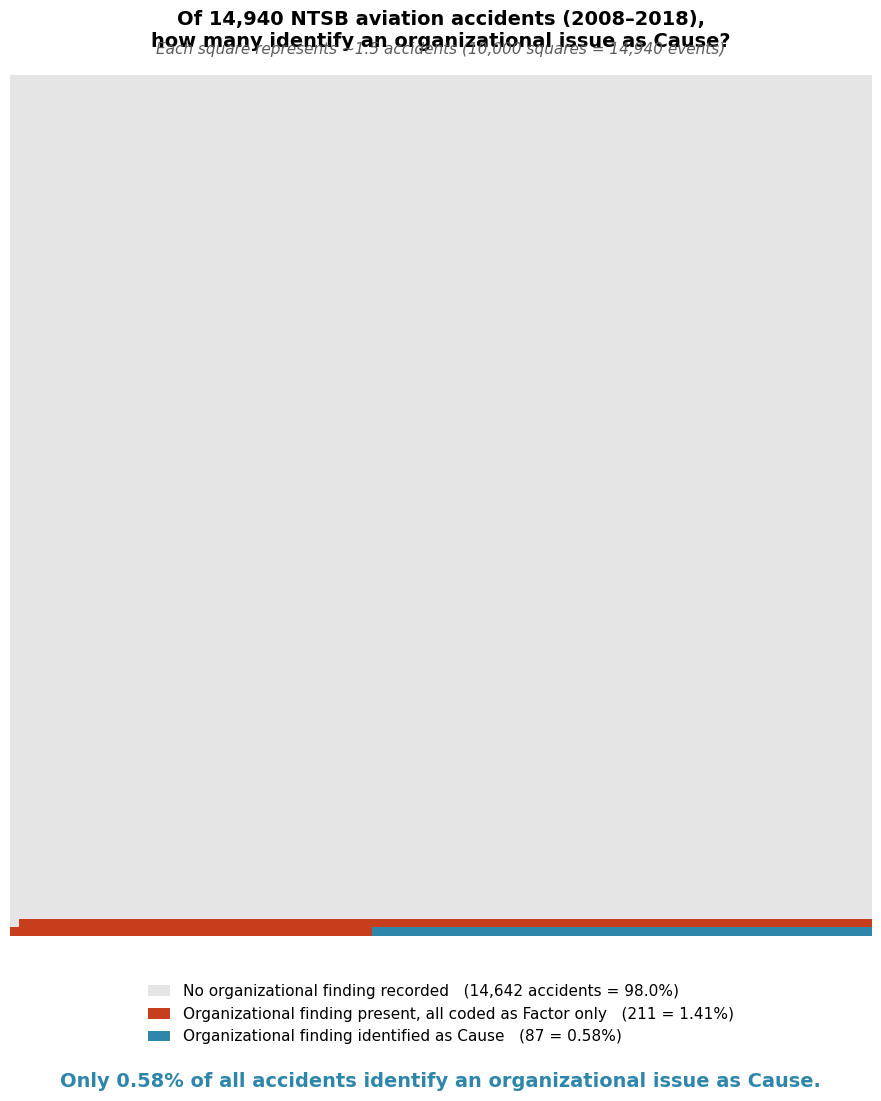

Saved: figure_6_double_displacement.png


In [25]:
# Figure 6 (re-do, FAST version): 100x100 grid using imshow
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap

# Numbers
total_events = 14940
events_with_org = 298
events_org_factor_only = 211
events_org_with_cause = 87
events_no_org = total_events - events_with_org

# Build 10,000-dot array
n_dots = 10000
dots_no_org = round(events_no_org / total_events * n_dots)
dots_factor_only = round(events_org_factor_only / total_events * n_dots)
dots_with_cause = n_dots - dots_no_org - dots_factor_only

states = np.zeros(n_dots, dtype=int)
states[dots_no_org : dots_no_org + dots_factor_only] = 1
states[dots_no_org + dots_factor_only :] = 2
grid = states.reshape(100, 100)

# Use imshow — single draw call, instant
fig, ax = plt.subplots(figsize=(11, 11))

cmap = ListedColormap(['#E5E5E5', '#C73E1D', '#2E86AB'])
ax.imshow(grid, cmap=cmap, aspect='equal', interpolation='nearest')

ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title('Of 14,940 NTSB aviation accidents (2008–2018),\n'
             'how many identify an organizational issue as Cause?',
             fontsize=14, fontweight='bold', pad=20)

fig.suptitle('Each square represents ~1.5 accidents (10,000 squares = 14,940 events)',
             fontsize=11, y=0.93, color='#5C5C5C', style='italic')

legend_items = [
    Patch(facecolor='#E5E5E5', label=f'No organizational finding recorded   ({events_no_org:,} accidents = 98.0%)'),
    Patch(facecolor='#C73E1D', label=f'Organizational finding present, all coded as Factor only   ({events_org_factor_only:,} = 1.41%)'),
    Patch(facecolor='#2E86AB', label=f'Organizational finding identified as Cause   ({events_org_with_cause:,} = 0.58%)'),
]
ax.legend(handles=legend_items, loc='upper center', bbox_to_anchor=(0.5, -0.04),
          fontsize=11, frameon=False, ncol=1, handlelength=1.5)

fig.text(0.5, -0.02, 
         'Only 0.58% of all accidents identify an organizational issue as Cause.',
         ha='center', fontsize=14, fontweight='bold', color='#2E86AB')

plt.tight_layout()
plt.savefig('figure_6_double_displacement.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: figure_6_double_displacement.png")